# L1.7 — The autopilot and the mission

**Level 1 · Core · 40 minutes**

**Goal.** You can give an aircraft a plan, and let one autopilot serve both airframes.

**Check at the end.** You can say why a position setpoint makes one autopilot enough for two very
different airframes.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. Three layers, and what each one owns

| Layer | Object | What it owns |
| --- | --- | --- |
| The plan | `Mission` | *What* to achieve. Pure geometry. It does not fly anything. |
| The navigator | `Autopilot` | *How* to turn the plan into a `MotionCommand`. |
| The controller | `Kinematics` | *How* to track that command inside the envelope. |

This is the PX4 split. The mission holds the plan, the navigator sequences it, and the position
controller flies it.

A `Mission` holds no speed and no capture radius. Those belong to the autopilot, not to the plan.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c"

from opencdarr import M600, SMALL_FIXEDWING, MotionCommand, create_aircraft, geo
from opencdarr.autopilot import CruiseAutopilot, GuidanceMemory, WaypointAutopilot
from opencdarr.autopilot.base import nominal_velocity
from opencdarr.kinematics import FixedWing, Multirotor
from opencdarr.mission import Mission, Waypoint

ORIGIN = (52.0, 4.0)

# a goto is the one-waypoint case; a flight plan is an ordered sequence
goto = Mission(goto=geo.forward(*ORIGIN, 45.0, 1200.0))
plan = Mission(flight_plan=(
    Waypoint(*geo.forward(*ORIGIN, 0.0, 900.0)),
    Waypoint(*geo.forward(*geo.forward(*ORIGIN, 0.0, 900.0), 90.0, 900.0)),
    Waypoint(*geo.forward(*geo.forward(*ORIGIN, 0.0, 300.0), 90.0, 1500.0)),
))

print(f"goto waypoints  {len(goto.waypoints())}")
print(f"plan waypoints  {len(plan.waypoints())}")
for k, wp in enumerate(plan.waypoints()):
    east, north = geo.enu(*ORIGIN, wp.lat, wp.lon)
    print(f"   {k}: {east:7.0f} m east, {north:7.0f} m north")

goto waypoints  1
plan waypoints  3
   0:       0 m east,     900 m north
   1:     900 m east,     900 m north
   2:    1500 m east,     300 m north


## 2. The autopilot contract

One method, and it is pure. Nothing is stored on the object.

```python
autopilot.step(state, memory, perf) -> (MotionCommand, GuidanceMemory)
autopilot.goal() -> (lat, lon) | None
```

`GuidanceMemory` carries the progress through the plan — today the active leg index. It goes **in**
and comes **out**. It is not an attribute of the autopilot.

The reason is Level 6. A rare-event estimator clones an aircraft in the middle of its plan, and the
clone has to resume on the same leg. So the progress must travel inside the value that is cloned,
not beside it.

Two autopilots ship:

- `CruiseAutopilot(heading, speed)` — hold one velocity. It has no goal, so it never triggers the
  stop-at-waypoint rule of `run_fleet`.
- `WaypointAutopilot(mission, cruise_airspeed=17.0, capture_radius=30.0, loiter_radius=80.0)` —
  fly the plan.

In [2]:
def channels(cmd: MotionCommand) -> dict[str, object]:
    return {f.name: getattr(cmd, f.name) for f in dataclasses.fields(cmd)
            if getattr(cmd, f.name) is not None}


copter = create_aircraft(M600, id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=12.0)

cruise = CruiseAutopilot(copter.trk, copter.gs)
waypoint = WaypointAutopilot(plan, cruise_airspeed=17.0, capture_radius=30.0)

for name, ap in (("CruiseAutopilot", cruise), ("WaypointAutopilot", waypoint)):
    cmd, mem = ap.step(copter, GuidanceMemory(), M600)
    print(f"{name}")
    print(f"    command   {channels(cmd)}")
    print(f"    memory    leg_index {mem.leg_index}")
    print(f"    goal      {ap.goal()}")

CruiseAutopilot
    command   {'target_velocity': (0.0, 12.0)}
    memory    leg_index 0
    goal      None
WaypointAutopilot
    command   {'target_position': (52.00810165117115, 4.0), 'target_airspeed': 17.0}
    memory    leg_index 0
    goal      (52.00269851370273, 4.021933430663384)


## 3. One autopilot, two airframes

`WaypointAutopilot` emits a **position** setpoint, not a velocity. That is the whole reason one
navigator serves both airframes: each airframe reads the same setpoint through its own physics.

- A `Multirotor` flies straight to the point and hovers.
- A `FixedWing` tracks the leg line to the point, and orbits the last one.

Fly the same plan with both. Thread the memory through each step, exactly as `run_fleet` does.

In [3]:
def fly_mission(state, kinematics, perf, mission, n: int, dt: float = 1.0, **ap_kwargs):
    """Fly a mission by hand: autopilot -> command -> kinematics, n times."""
    ap = WaypointAutopilot(mission, **ap_kwargs)
    memory = GuidanceMemory()
    states, legs = [state], [memory.leg_index]
    for _ in range(n):
        command, memory = ap.step(states[-1], memory, perf)
        states.append(kinematics.step(states[-1], command, perf, dt))
        legs.append(memory.leg_index)
    return states, legs


copter0 = create_aircraft(M600, id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=12.0)
plane0 = create_aircraft(SMALL_FIXEDWING, id="PLANE", lat=52.0, lon=4.0, trk=0.0, gs=17.0)

copter_states, copter_legs = fly_mission(copter0, Multirotor(), M600, plan, 320)
plane_states, plane_legs = fly_mission(plane0, FixedWing(), SMALL_FIXEDWING, plan, 320,
                                       cruise_airspeed=17.0)

print(f"{'':<10}{'distance flown':>17}{'final leg':>12}{'final speed':>14}")
for name, states, legs in (("copter", copter_states, copter_legs),
                           ("plane", plane_states, plane_legs)):
    print(f"{name:<10}{states[-1].distance_flown:>15.0f} m{legs[-1]:>12}"
          f"{states[-1].gs:>12.1f} m/s")

             distance flown   final leg   final speed
copter               2670 m           2         0.0 m/s
plane                5440 m           2        17.0 m/s


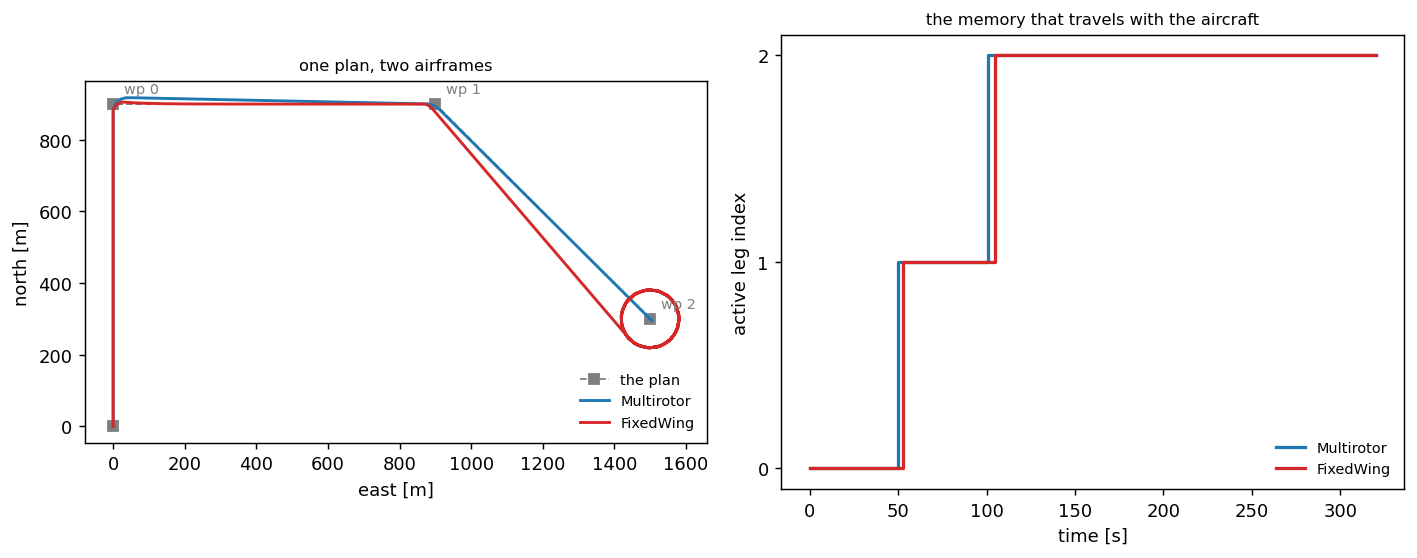

In [4]:
def xy(states) -> np.ndarray:
    return np.array([geo.enu(*ORIGIN, s.lat, s.lon) for s in states])


wps = np.array([geo.enu(*ORIGIN, w.lat, w.lon) for w in plan.waypoints()])

fig, (ax_p, ax_l) = plt.subplots(1, 2, figsize=(11.0, 4.4))

ax_p.plot(np.r_[0, wps[:, 0]], np.r_[0, wps[:, 1]], ls="--", lw=1.0, color=GREY,
          marker="s", ms=5, label="the plan")
for states, colour, label in ((copter_states, BLUE, "Multirotor"),
                              (plane_states, RED, "FixedWing")):
    p = xy(states)
    ax_p.plot(p[:, 0], p[:, 1], lw=1.6, color=colour, label=label)
for k, (e, n) in enumerate(wps):
    ax_p.annotate(f"wp {k}", (e, n), (6, 6), textcoords="offset points", fontsize=8, color=GREY)
ax_p.set_aspect("equal")
ax_p.set_xlabel("east [m]")
ax_p.set_ylabel("north [m]")
ax_p.set_title("one plan, two airframes", fontsize=9)
ax_p.legend(frameon=False, fontsize=8, loc="lower right")

ax_l.step(np.arange(len(copter_legs)), copter_legs, where="post", lw=1.8, color=BLUE,
          label="Multirotor")
ax_l.step(np.arange(len(plane_legs)), plane_legs, where="post", lw=1.8, color=RED,
          label="FixedWing")
ax_l.set_yticks(range(len(plan.waypoints())))
ax_l.set_xlabel("time [s]")
ax_l.set_ylabel("active leg index")
ax_l.set_title("the memory that travels with the aircraft", fontsize=9)
ax_l.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()

## 4. The capture radius cuts the corner

`capture_radius` is how near the aircraft must be before the autopilot advances to the next leg. It
is a property of the navigator, not of the plan.

A small radius makes a tight, late corner. A large radius makes an early, wide one. For a fixed-wing
it must be large enough that the aircraft can reach it: below the turn radius, the aircraft can
circle a waypoint it never captures.

In [5]:
print(f"{'capture_radius':>16}{'distance flown':>17}{'final leg':>12}")
corners = {}
for radius in (10.0, 30.0, 120.0, 300.0):
    states, legs = fly_mission(copter0, Multirotor(), M600, plan, 320, capture_radius=radius)
    corners[radius] = xy(states)
    print(f"{radius:>16.0f}{states[-1].distance_flown:>15.0f} m{legs[-1]:>12}")

  capture_radius   distance flown   final leg
              10           2756 m           2
              30           2670 m           2
             120           2590 m           2
             300           2420 m           2


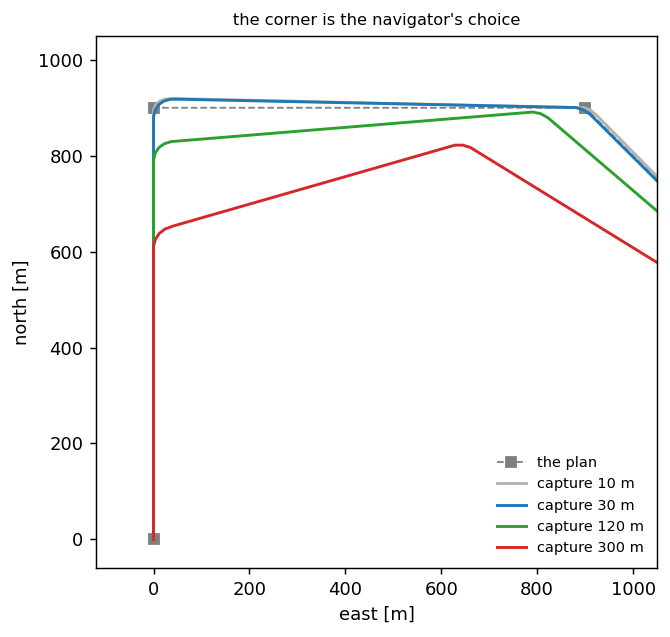

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.plot(np.r_[0, wps[:, 0]], np.r_[0, wps[:, 1]], ls="--", lw=1.0, color=GREY, marker="s", ms=5,
        label="the plan")
for (radius, p), colour in zip(corners.items(), ("0.7", BLUE, GREEN, RED)):
    ax.plot(p[:, 0], p[:, 1], lw=1.6, color=colour, label=f"capture {radius:.0f} m")
ax.set_aspect("equal")
ax.set_xlim(-120, 1050)
ax.set_ylim(-60, 1050)
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.set_title("the corner is the navigator's choice", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()

## 5. What the aircraft intends

`nominal_velocity(command, state)` reads a command back as the velocity the aircraft **intends** to
fly. The loop stamps it on `AircraftState.desired` at each tick.

Lesson L1.10 needs it. `FTR` asks "is it safe to go back to my plan?", and the plan it tests against
is this live nominal, not a value frozen at the start of the run.

- A velocity command is returned unchanged.
- A position command becomes "head at the active waypoint, at the cruise airspeed".

In [7]:
for name, ap, state in (("CruiseAutopilot", cruise, copter0),
                        ("WaypointAutopilot", waypoint, copter0)):
    cmd, _ = ap.step(state, GuidanceMemory(), M600)
    want = nominal_velocity(cmd, state)
    print(f"{name:<20} desired trk {want.trk:6.1f} deg   gs {want.gs:5.1f} m/s")

# the nominal turns with the plan: read it again part way along each leg
print()
for t in (60, 140):
    state = copter_states[t]
    cmd, _ = WaypointAutopilot(plan).step(state, GuidanceMemory(leg_index=copter_legs[t]), M600)
    want = nominal_velocity(cmd, state)
    print(f"at t = {t:>3} s, on leg {copter_legs[t]}:  desired trk {want.trk:6.1f} deg   "
          f"gs {want.gs:5.1f} m/s")

# once it arrives and hovers, the nominal points back at the waypoint it is sitting on
parked = copter_states[300]
cmd, _ = WaypointAutopilot(plan).step(parked, GuidanceMemory(leg_index=copter_legs[300]), M600)
print(f"at t = 300 s, parked on the last waypoint:  desired trk "
      f"{nominal_velocity(cmd, parked).trk:6.1f} deg   <- read nothing into this one")

CruiseAutopilot      desired trk    0.0 deg   gs  12.0 m/s
WaypointAutopilot    desired trk    0.0 deg   gs  17.0 m/s

at t =  60 s, on leg 1:  desired trk   91.2 deg   gs  17.0 m/s
at t = 140 s, on leg 2:  desired trk  134.9 deg   gs  17.0 m/s
at t = 300 s, parked on the last waypoint:  desired trk  314.9 deg   <- read nothing into this one


## Do it yourself

1. Give the fixed-wing a `loiter_radius` of 200 m. Run section 3 again and measure the final orbit.
2. Set `capture_radius=5.0` for the fixed-wing. Find the waypoint it cannot capture.
3. Make a `Mission(goto=...)` and give it to both airframes. Compare what each does on arrival.
4. Build a four-waypoint plan of your own. Check that `leg_index` reaches 3.

## Check

1. Why does a position setpoint make one autopilot enough for two very different airframes?
2. Why does the leg index travel in `GuidanceMemory` instead of on the autopilot object?
3. `CruiseAutopilot.goal()` returns `None`. What does that stop `run_fleet` from doing?

## Next

`L1.8 — Conflict detection`. The aircraft can fly a plan. Next you find out when the plan is going
to fail.